In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import json

/home/aryan/HestaBit_Training/Github/Week8-1/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
tokenizer = AutoTokenizer.from_pretrained(
"TinyLlama/TinyLlama-1.1B-Chat-v1.0"
)

In [4]:
data = []

with open("../data/train.jsonl") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [5]:
df["tokens"] = df.apply(
lambda x: len(tokenizer(x["instruction"] + x["input"] + x["output"]).input_ids),
axis=1
)

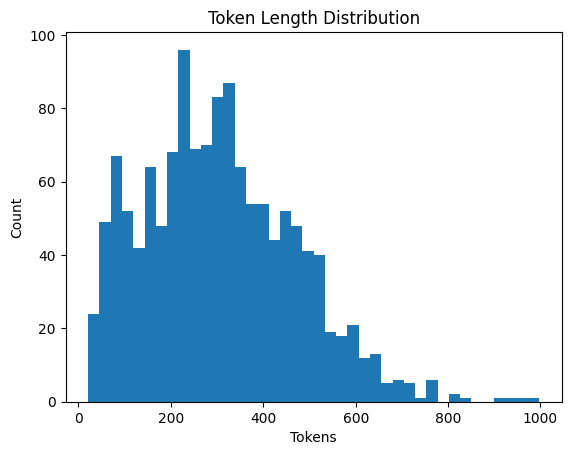

In [11]:
plt.hist(df["tokens"], bins=40)
plt.title("Token Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>